In [12]:
import sys
from pathlib import Path
import json
import pinecone
import requests
import time
from typing import List, Dict, Any
from dotenv import load_dotenv
import os


# notebook lives in backend/app/chat/
chat_dir = Path.cwd()
backend_dir = chat_dir.parent.parent
repo_root = backend_dir.parent

sys.path.append(str(backend_dir))
sys.path.append(str(repo_root))


In [13]:
from typing import Annotated, Optional, TypedDict
import uuid

from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from pydantic import BaseModel, Field

from tools import calculate_financial_wellbeing, calculate_amortization, get_macro_context
from law_retrieval import retrieve_laws

# Same model factory law_retrieval.py already uses - no second LLM config path.
from app.chat.langgraph_agent import create_model

FINANCIAL_TOOLS = [calculate_financial_wellbeing, calculate_amortization, get_macro_context]

# One model reused for both planning and extraction (different structured
# schemas bound per call) - swap for two different models later if you want
# a cheaper model for one of the two jobs.
planner_llm = create_model("qwen/qwen3.7-flash")
extractor_llm = create_model("qwen/qwen3.7-flash")
answer_llm = create_model("qwen/qwen3-max")  # swap for whatever your real answer model is


In [14]:
# %% [markdown]
# ## State

class PipelineState(TypedDict):
    user_query: str
    persona_prompt: str                                 # supplied at invoke time, cached upstream
    tool_plan: dict                                     # structured output from the planner node
    tool_messages: Annotated[liwst, add_messages]        # feature_extraction + tool_executor scratch space
    missing_info: dict                                  # {tool_name: [missing_field, ...]} - populated by feature_extraction
    law_chunks: list
    system_prompt: str
    final_answer: str
    fact_check_attempts: int                            # bounds the regenerate loop below
    fact_check_feedback: list                           # unsupported claims from the last fact-check, fed back into a retry


# %% [markdown]
# ## Node: planner
# Replaces financial_router. Decides WHICH tools are needed via structured
# output (a typed Pydantic object), not native tool-calling - it does not
# see or produce tool arguments. That's feature_extraction's job, next.

class ToolPlan(BaseModel):
    """Which financial tools (if any) this query needs. Do not guess - only
    mark a tool True if the query gives, or unambiguously implies, what that
    tool needs, or the user is plainly asking for that exact computation."""

    calculate_financial_wellbeing: bool = Field(
        description="True only if the user gave income/expenses/savings/debt "
        "figures, or explicitly asks to assess their financial wellbeing."
    )
    calculate_amortization: bool = Field(
        description="True only if the user gave (or the question is clearly "
        "about) a loan principal, interest rate, and term."
    )
    get_macro_context: bool = Field(
        description="True only if the question needs current macroeconomic "
        "indicators (inflation, rates, unemployment, GDP growth) to answer well."
    )
    reasoning: str = Field(description="One sentence explaining the decision.")


PLANNER_SYSTEM_PROMPT = """
You are the planning layer for a financial advisory assistant with 3 tools:

- calculate_financial_wellbeing: scores income/expenses/savings/debt.
- calculate_amortization: builds a loan repayment schedule.
- get_macro_context: fetches current macroeconomic indicators for a country.

Decide which of these (if any) this specific query needs. Do NOT guess
missing numeric values and do NOT flag a tool "just in case" - if the
message is a pure eligibility/legal question with no numbers, flag nothing.
You are only deciding WHICH tools are relevant; you are not extracting their
arguments.
"""

planner_structured = planner_llm.with_structured_output(ToolPlan)


def planner_node(state: PipelineState) -> dict:
    plan: ToolPlan = planner_structured.invoke([
        SystemMessage(content=PLANNER_SYSTEM_PROMPT),
        HumanMessage(content=state["user_query"]),
    ])
    return {"tool_plan": plan.model_dump()}


def route_after_planner(state: PipelineState) -> str:
    """The conditional edge: branch on whether the planner flagged any tool."""
    plan = state["tool_plan"]
    needs_any_tool = any(
        plan[name]
        for name in ("calculate_financial_wellbeing", "calculate_amortization", "get_macro_context")
    )
    return "feature_extraction" if needs_any_tool else "law_retrieval"


NameError: name 'liwst' is not defined

In [ ]:
# %% [markdown]
# ## Node: feature_extraction
# For every tool the planner flagged True, extract that tool's argument
# values from the user's query. If a REQUIRED value simply isn't in the
# query, it stays None - we never substitute 0 or any other guessed
# default, and that tool is NOT called this turn. Instead it's recorded in
# missing_info so assemble_context can tell the final LLM to ask the user
# for exactly those values, rather than silently running the calculation
# with fabricated numbers. Fields the underlying tool itself treats as
# optional (has a default for) are allowed to stay None - those are simply
# left out of the call and the tool's own default applies.

class FinancialWellbeingArgs(BaseModel):
    monthly_income: Optional[float] = Field(
        default=None, description="Take-home income per month. Null if not stated."
    )
    monthly_expenses: Optional[float] = Field(
        default=None, description="Regular monthly spending. Null if not stated."
    )
    savings_balance: Optional[float] = Field(
        default=None, description="Current liquid savings. Null if not stated."
    )
    total_debt_amount: Optional[float] = Field(
        default=None,
        description="Total outstanding debt. Null if not stated - do NOT assume zero.",
    )


class AmortizationArgs(BaseModel):
    principal: Optional[float] = Field(default=None, description="Loan amount. Null if not stated.")
    annual_interest_rate: Optional[float] = Field(
        default=None, description="Annual interest rate as a percent, e.g. 6.5. Null if not stated."
    )
    term_months: Optional[int] = Field(default=None, description="Loan term in months. Null if not stated.")


class MacroContextArgs(BaseModel):
    country_code: Optional[str] = Field(
        default=None,
        description="2- or 3-letter ISO country code implied by the query. Null if none is mentioned.",
    )


TOOL_ARG_SCHEMAS = {
    "calculate_financial_wellbeing": FinancialWellbeingArgs,
    "calculate_amortization": AmortizationArgs,
    "get_macro_context": MacroContextArgs,
}

# Fields the underlying tool call CANNOT proceed without (no default in the
# tool's own signature). Anything not listed here is optional at the tool
# level, so a null just means "let the tool use its own default".
REQUIRED_FIELDS = {
    "calculate_financial_wellbeing": ["monthly_income", "monthly_expenses", "savings_balance"],
    "calculate_amortization": ["principal", "annual_interest_rate", "term_months"],
    "get_macro_context": [],  # country_code defaults to "gr" in the tool itself
}

FEATURE_EXTRACTION_PROMPT = (
    "Extract the arguments for {tool_name} from the user's message below. "
    "Only fill in a value the user actually stated. If a value is not "
    "present in the message, leave it null - never guess, estimate, or "
    "default it to zero."
)


def feature_extraction_node(state: PipelineState) -> dict:
    plan = state["tool_plan"]
    # Tolerate either shape: planner_node stores plan.model_dump() (a dict),
    # but a standalone test invoking this node directly might hand it a raw
    # ToolPlan instance instead - normalize so both work the same way.
    if isinstance(plan, BaseModel):
        plan = plan.model_dump()

    tool_calls = []
    missing_info = {}

    for tool_name, schema in TOOL_ARG_SCHEMAS.items():
        if not plan.get(tool_name):
            continue

        extractor = extractor_llm.with_structured_output(schema)
        args: BaseModel = extractor.invoke([
            SystemMessage(content=FEATURE_EXTRACTION_PROMPT.format(tool_name=tool_name)),
            HumanMessage(content=state["user_query"]),
        ])
        args_dict = args.model_dump()

        missing = [f for f in REQUIRED_FIELDS[tool_name] if args_dict.get(f) is None]
        if missing:
            missing_info[tool_name] = missing
            continue  # do NOT call this tool until every required value is present

        # Drop optional fields that stayed None so the tool's own default applies
        # instead of us passing an explicit (and possibly wrong) value.
        clean_args = {k: v for k, v in args_dict.items() if v is not None}

        tool_calls.append({
            "name": tool_name,
            "args": clean_args,
            "id": str(uuid.uuid4()),
        })

    ai_msg = AIMessage(content="", tool_calls=tool_calls)
    return {"tool_messages": [ai_msg], "missing_info": missing_info}


In [ ]:
# %% [markdown]
# ## Node: tool_executor (prebuilt - just executes whatever feature_extraction asked for)
# Unchanged except messages_key, since the scratch-space field is now
# tool_messages instead of router_messages.

tool_executor = ToolNode(FINANCIAL_TOOLS, messages_key="tool_messages")


In [ ]:
# %% [markdown]
# ## Node: law_retrieval
# Thin wrapper around the pipeline you already built. It self-gates
# (should_run_law_retrieval) and self-decomposes, so nothing extra is needed here.

def law_retrieval_node(state: PipelineState) -> dict:
    return {"law_chunks": retrieve_laws(state["user_query"])}


# %% [markdown]
# ## Node: assemble_context
# Only change from before: reads state["tool_messages"] instead of
# state["router_messages"].

def assemble_context(state: PipelineState) -> dict:
    tool_outputs = {
        msg.name: msg.content
        for msg in state["tool_messages"]
        if isinstance(msg, ToolMessage)
    }

    sections = [state["persona_prompt"].strip(), ""]

    if tool_outputs:
        sections.append("FINANCIAL CONTEXT (computed for this specific query):")
        for name, result in tool_outputs.items():
            sections.append(f"- {name} -> {result}")
        sections.append("")

    missing_info = state.get("missing_info", {})
    if missing_info:
        sections.append(
            "MISSING INPUTS (do NOT guess these - ask the user to provide "
            "them before that calculation can run):"
        )
        for tool_name, fields in missing_info.items():
            sections.append(f"- {tool_name} is missing: {', '.join(fields)}")
        sections.append("")

    law_chunks = state["law_chunks"]
    if law_chunks:
        sections.append(
            "RELEVANT LAWS (reason explicitly about eligibility/compliance using "
            "these, and cite each one you rely on by law_name + article):"
        )
        for chunk in law_chunks:
            meta = chunk.get("metadata", {})
            sections.append(
                f"- [{meta.get('law_name', 'Unknown law')} "
                f"{meta.get('article', '')}] {meta.get('condition', '')}"
            )
        sections.append("")

    sections.append(
        "Instructions: Answer using the persona's tone/style above. If "
        "financial context was computed, use those real numbers - don't "
        "re-derive them. If any inputs are listed as missing above, ask the "
        "user directly for exactly those values instead of estimating, "
        "assuming a default, or skipping the calculation silently. If laws "
        "were retrieved, ground any legal/eligibility claim in a specific "
        "cited law; if none were retrieved, don't fabricate legal claims."
    )

    print("SYSTEM_PROMPT", "\n".join(sections))

    return {"system_prompt": "\n".join(sections)}


In [ ]:
def generate_answer(state: PipelineState) -> dict:
    messages = [SystemMessage(content=state["system_prompt"])]

    # Only present on a retry after fact_check found unsupported claims.
    feedback = state.get("fact_check_feedback")
    if feedback:
        messages.append(SystemMessage(content=
            "Your previous answer included claims not supported by the "
            "retrieved sources: " + "; ".join(feedback) + ". Rewrite the "
            "answer - remove or correct these. Only state what the source "
            "material actually supports."
        ))

    messages.append(HumanMessage(content=state["user_query"]))
    response = answer_llm.invoke(messages)
    return {"final_answer": response.content}


In [ ]:
# %% [markdown]
# ## Node: fact_check (+ attach_disclaimer)
# Only runs when law_chunks is non-empty - no laws retrieved means nothing
# to hallucinate a citation from, so cheap turns skip this entirely (see
# route_after_generate_answer below). Checks the draft answer's specific
# citations and figures against the actual retrieved law_chunks - nothing
# else. Loops back to generate_answer (max 2 retries) on a miss; if still
# unresolved, attaches a disclaimer rather than silently shipping an
# unverified legal claim.

class FactCheckResult(BaseModel):
    grounded: bool = Field(
        description="True only if every specific legal citation (law name, "
        "article, directive number) and every specific figure (amounts, "
        "percentages, thresholds) in the answer is directly supported by "
        "the source material below - not general knowledge, not merely "
        "plausible-sounding detail."
    )
    unsupported_claims: list[str] = Field(
        default_factory=list,
        description="Exact phrases from the answer not supported by the source material. Empty if grounded is True.",
    )


FACT_CHECK_PROMPT = """
You are a strict fact-checker. You are shown SOURCE MATERIAL and an ANSWER
that was supposed to be based on it. Check every specific legal citation
and every specific number in the answer against the source material only.

If the answer states a citation or figure that does not appear in the
source material - even if it sounds accurate or plausible - mark it
unsupported. Do not use your own general knowledge to "confirm" a claim.
"""

# Verification benefits from a stronger model than the cheap router/extractor
# ones above - a weak judge will miss subtle fabrications. Swap freely.
fact_check_llm = create_model("qwen/qwen3-max")
fact_check_structured = fact_check_llm.with_structured_output(FactCheckResult)

MAX_FACT_CHECK_RETRIES = 2

def _format_law_sources(law_chunks: list) -> str:
    lines = []
    for chunk in law_chunks:
        meta = chunk.get("metadata", {})
        lines.append(f"- [{meta.get('law_name', '')} {meta.get('article', '')}] {meta.get('condition', '')}")
    return "\n".join(lines)


def fact_check_node(state: PipelineState) -> dict:
    source_material = _format_law_sources(state["law_chunks"])
    result: FactCheckResult = fact_check_structured.invoke([
        SystemMessage(content=FACT_CHECK_PROMPT),
        HumanMessage(content=f"SOURCE MATERIAL:\n{source_material}\n\nANSWER:\n{state['final_answer']}"),
    ])

    return {
        "fact_check_attempts": state.get("fact_check_attempts", 0) + 1,
        "fact_check_feedback": [] if result.grounded else result.unsupported_claims,
    }


def attach_disclaimer_node(state: PipelineState) -> dict:
    disclaimer = (
        "\n\n---\n*Some legal details above could not be fully verified "
        "against the retrieved sources. Please confirm specifics with a "
        "licensed legal or financial advisor before relying on them.*"
    )
    return {"final_answer": state["final_answer"] + disclaimer}


def route_after_generate_answer(state: PipelineState) -> str:
    """Skip fact-checking entirely when no laws were retrieved - nothing to hallucinate a citation from."""
    return "fact_check" if state["law_chunks"] else "end"


def route_after_fact_check(state: PipelineState) -> str:
    if not state["fact_check_feedback"]:
        return "end"
    if state["fact_check_attempts"] >= MAX_FACT_CHECK_RETRIES:
        return "disclaim"
    return "retry"


In [ ]:
# %% [markdown]
# ## Build the graph
# planner -> (conditional) -> feature_extraction -> tool_executor -> law_retrieval
# planner -> (conditional) -------------------------------------> law_retrieval
# law_retrieval -> assemble_context -> generate_answer -> (conditional) -> fact_check -> (conditional) -> END
#                                                       -> (conditional, no laws) -----------------------> END
# fact_check -> (conditional, unresolved) -> attach_disclaimer -> END
# fact_check -> (conditional, retry)      -> generate_answer   [loop, max 2 attempts]

graph = StateGraph(PipelineState)

graph.add_node("planner", planner_node)
graph.add_node("feature_extraction", feature_extraction_node)
graph.add_node("tool_executor", tool_executor)
graph.add_node("law_retrieval", law_retrieval_node)
graph.add_node("assemble_context", assemble_context)
graph.add_node("generate_answer", generate_answer)
graph.add_node("fact_check", fact_check_node)
graph.add_node("attach_disclaimer", attach_disclaimer_node)

graph.add_edge(START, "planner")
graph.add_conditional_edges(
    "planner",
    route_after_planner,
    {"feature_extraction": "feature_extraction", "law_retrieval": "law_retrieval"},
)
graph.add_edge("feature_extraction", "tool_executor")
graph.add_edge("tool_executor", "law_retrieval")
graph.add_edge("law_retrieval", "assemble_context")
graph.add_edge("assemble_context", "generate_answer")

graph.add_conditional_edges(
    "generate_answer",
    route_after_generate_answer,
    {"fact_check": "fact_check", "end": END},
)
graph.add_conditional_edges(
    "fact_check",
    route_after_fact_check,
    {"end": END, "retry": "generate_answer", "disclaim": "attach_disclaimer"},
)
graph.add_edge("attach_disclaimer", END)

app = graph.compile()


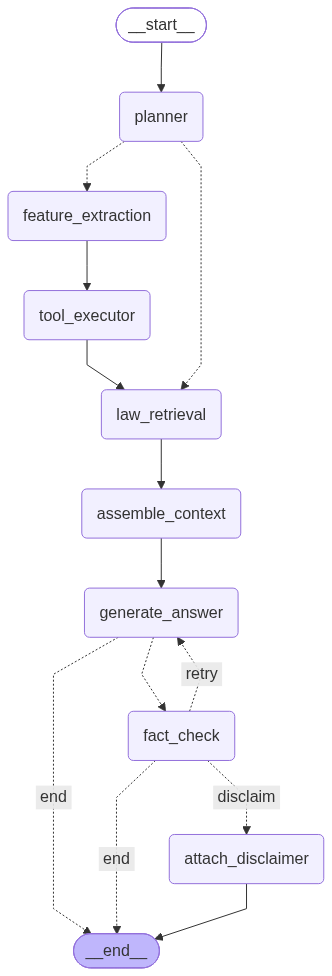

In [15]:
app

In [16]:
if __name__ == "__main__":
    demo_persona_prompt = (
        "USER PERSONA: The Cautious Realist\n"
        "This user has HIGH debt aversion and HIGH risk aversion.\n"
        "- Be transparent and evidence-based\n"
        "- Show concrete data (interest rates, repayment schedules)\n"
        "- Highlight regulatory protections"
    )

    initial_state: PipelineState = {
        "user_query": "I am 14 years old applying for a loan for a startup business, can I?",
        "persona_prompt": demo_persona_prompt,
        "tool_plan": {},
        "tool_messages": [],
        "missing_info": {},
        "law_chunks": [],
        "system_prompt": "",
        "final_answer": "",
        "fact_check_attempts": 0,
        "fact_check_feedback": [],
    }

    result = app.invoke(initial_state)
    print("fact_check_attempts:", result["fact_check_attempts"])
    print(result["final_answer"])


INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


{'needs_law_retrieval': True}


INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"


fact_check_attempts: 1
Unfortunately, **you cannot legally take out a loan for a startup business at age 14** in Greece (or in most jurisdictions). Here’s why—based on legal, financial, and regulatory facts:

### 1. **Legal Capacity to Enter Contracts**
Under Greek civil law, minors under the age of **18** do not have full legal capacity to enter into binding contracts—including loan agreements—without the consent or representation of a legal guardian (typically a parent). Even with parental consent, most credit institutions **will not approve loans to minors**, especially for high-risk purposes like startups, because:
- You lack independent income sufficient to service debt.
- There is no established credit history.
- Startups carry significant business risk, which conflicts with prudent lending standards.

> *Note: This isn't a policy choice—it's a structural limitation rooted in contract law and banking regulation.*

---

### 2. **Banking & Lending Regulations**
Credit institutions 